In [2]:
#importing all required libraries

#pytorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

#for data handling
import numpy as np
import pandas as pd

# for visualizing
import matplotlib.pyplot as plt

#to save model weights
import pickle

In [3]:
#loading fashion MNIST csv files
train_df = pd.read_csv("FASHION/fashion-mnist_train.csv")
test_df = pd.read_csv("FASHION/fashion-mnist_test.csv")

In [4]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
train_df.shape ,test_df.shape

((60000, 785), (10000, 785))

In [6]:
len(train_df['label'].unique()) #no. of classes

10

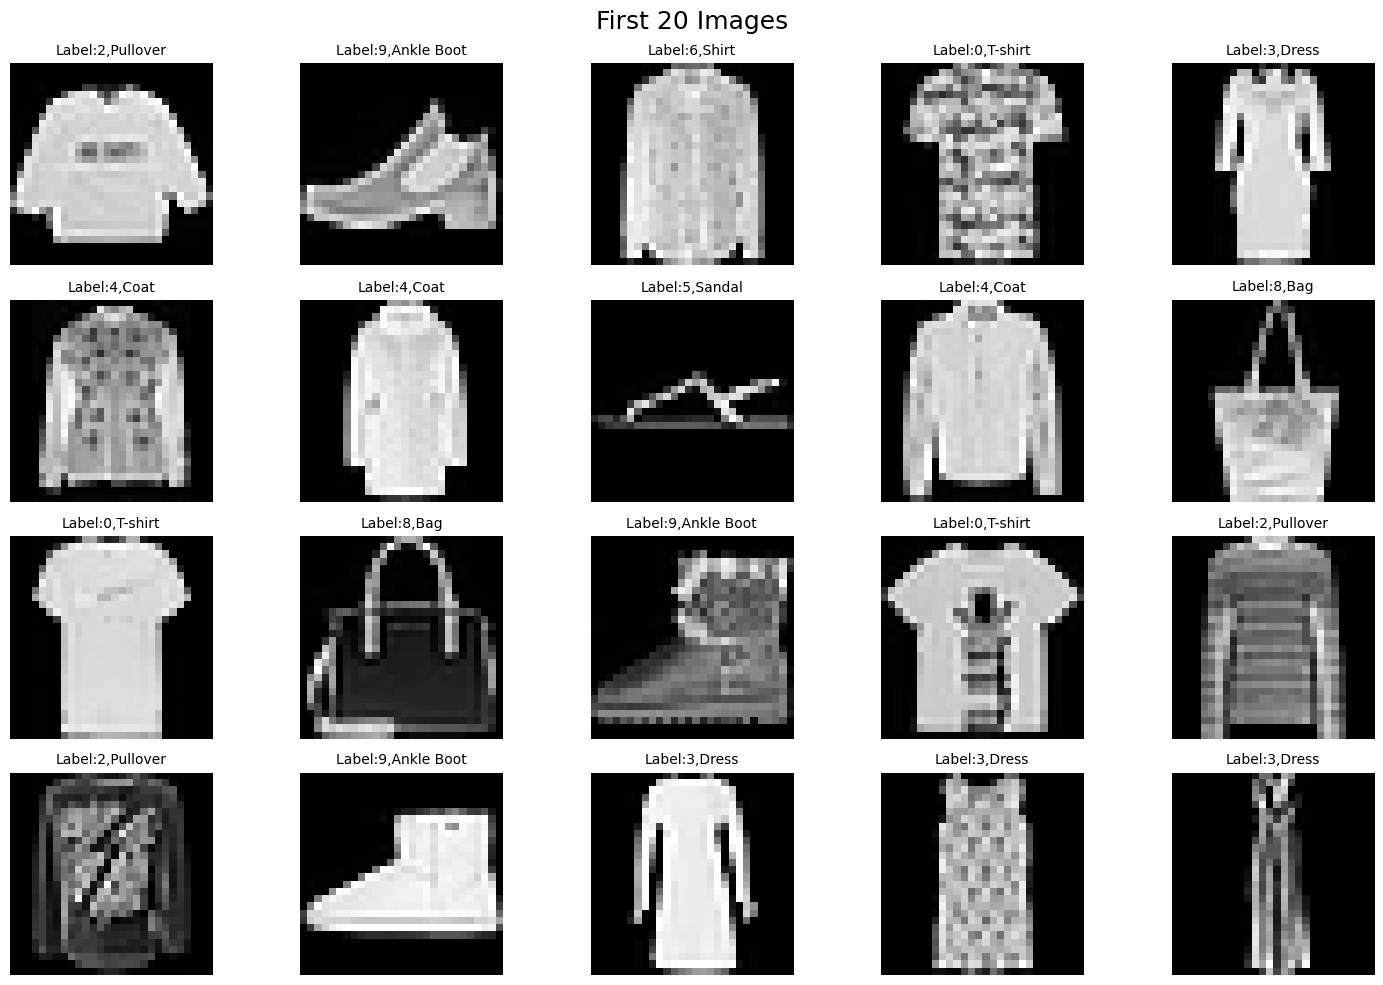

In [7]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]
# to visualize 1 st 20 images in train dataset
fig, axes = plt.subplots(4, 5, figsize=(15, 10))
fig.suptitle("First 20 Images", fontsize=18)

for idx, ax in enumerate(axes.ravel()):

    image = train_df.iloc[idx, 1:].values.reshape(28, 28)
    label = train_df.iloc[idx, 0]

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label:{label},{class_names[label]}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
#creating a custom dataset class
class FashionMNIST(Dataset):
    
    def __init__(self, dataframe):
        self.images = dataframe.iloc[:, 1:].values.astype("float32") / 255 # setting pixel values to range (0,1)
        self.labels = dataframe.iloc[:, 0].values

    def __len__(self):#no. of samples
        return len(self.labels)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx]).reshape(1, 28, 28) # (no. of channels, 28 ,28)

        label = torch.tensor(self.labels[idx],dtype=torch.long)

        return image, label

In [9]:
dataset = FashionMNIST(train_df) # create dataset objects

train_size = int(0.8 * len(dataset))
val_size = int(0.2 * len(dataset))

train_dataset, val_dataset = random_split( dataset, [train_size, val_size])

#creating data loaders for batch processing
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [10]:
#creating neuralnet class

class Neuralnet(nn.Module):
    def __init__(self):
        super().__init__()

        # fully connected layer 1
        self.fc1 = nn.Linear(784, 16)

        # left side
        self.left1 = nn.Linear(16, 8)
        self.left2 = nn.Linear(8, 8)

        # right side
        self.right1 = nn.Linear(16, 12)
        self.right2 = nn.Linear(12, 8)

        self.output = nn.Linear(16, 10)

        self.relu = nn.ReLU()

    #for forward pass
    def forward(self, x):

        x = x.view(x.size(0), -1) # flattening the image

        x = self.relu(self.fc1(x))

        #left branch
        left = self.relu(self.left1(x))
        skip = left
        left = self.relu(self.left2(left))
        left = left + skip

        #right branch
        right = self.relu(self.right1(x))
        right = self.relu(self.right2(right))

        merged = torch.cat([left, right], dim=1) #concatenating

        out = self.output(merged) # output layer

        return out

In [11]:
device = torch.device("cuda" if torch.cuda.is_available()else "cpu")

model = Neuralnet().to(device)

In [12]:
criterion = nn.CrossEntropyLoss()# cross entropy loss as cost criterion
optimizer = torch.optim.Adam(model.parameters(),lr=0.001) # Adam optimizer

In [13]:
epochs = 20

train_losses = []
val_losses = []

train_accs = []
val_accs = []

In [14]:
best_epoch = 0
best_val_acc = 0

for epoch in range(epochs):

    model.train()

    running_loss = 0
    n_correct = 0
    n_samples = 0

    for i ,(images,labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        preds = model(images) #forward propagation
        loss = criterion(preds, labels)

        optimizer.zero_grad() # to clear previous gradients

        loss.backward() #backpropagation

        optimizer.step() # updates weights

        running_loss += loss.item()

        _, predicted = torch.max(preds, 1)

        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * n_correct / n_samples

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation

    model.eval()

    running_loss = 0
    n_correct = 0
    n_samples = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            preds = model(images)
            
            loss = criterion(preds, labels)
            running_loss += loss.item()

            _, predicted = torch.max(preds, 1)

            n_samples += labels.size(0)
            n_correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100 * n_correct / n_samples

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_epoch = epoch + 1
        best_val_acc = val_acc
        
        with open("best_model.pkl","wb") as f: # saves model with highest validation accuracy
            pickle.dump(model.state_dict(),f)
    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Training Loss:{train_loss:.4f} "
        f"Training Accuracy:{train_acc:.2f}% "
        f"Validation Loss:{val_loss:.4f} "
        f"Validation Accuracy:{val_acc:.2f}%"
    )

Epoch [1/20] Training Loss:0.8398 Training Accuracy:69.99% Validation Loss:0.5273 Validation Accuracy:81.00%
Epoch [2/20] Training Loss:0.5087 Training Accuracy:81.96% Validation Loss:0.4790 Validation Accuracy:83.10%
Epoch [3/20] Training Loss:0.4679 Training Accuracy:83.41% Validation Loss:0.4746 Validation Accuracy:83.30%
Epoch [4/20] Training Loss:0.4415 Training Accuracy:84.30% Validation Loss:0.4364 Validation Accuracy:84.86%
Epoch [5/20] Training Loss:0.4260 Training Accuracy:84.89% Validation Loss:0.4349 Validation Accuracy:84.54%
Epoch [6/20] Training Loss:0.4116 Training Accuracy:85.31% Validation Loss:0.4168 Validation Accuracy:85.22%
Epoch [7/20] Training Loss:0.3986 Training Accuracy:85.90% Validation Loss:0.4034 Validation Accuracy:85.77%
Epoch [8/20] Training Loss:0.3906 Training Accuracy:85.99% Validation Loss:0.4029 Validation Accuracy:85.83%
Epoch [9/20] Training Loss:0.3810 Training Accuracy:86.48% Validation Loss:0.3948 Validation Accuracy:86.08%
Epoch [10/20] Train

In [15]:
print(f"Best Epoch: {best_epoch}")
print(f"\nBest Validation Accuracy: :{best_val_acc:.2f}%")

Best Epoch: 16

Best Validation Accuracy: :86.55%


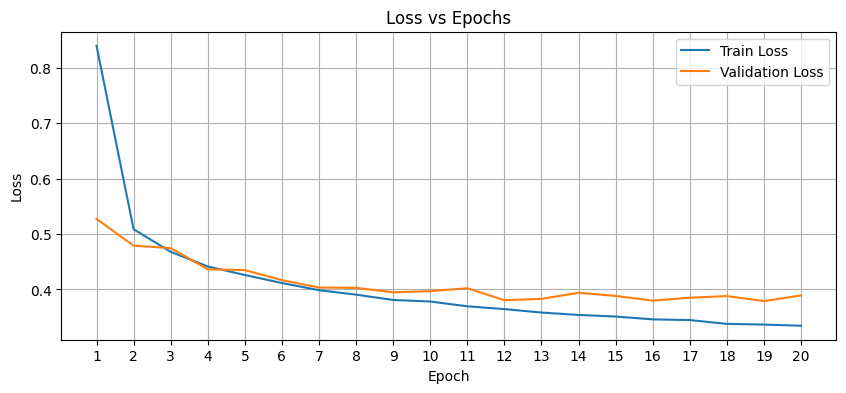

In [16]:
epoch_nums = range(1, epochs + 1)

plt.figure(figsize=(10,4))

plt.plot(epoch_nums, train_losses, label="Train Loss")
plt.plot(epoch_nums, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epoch_nums)
plt.legend()
plt.title("Loss vs Epochs")
plt.grid(True)
plt.show()

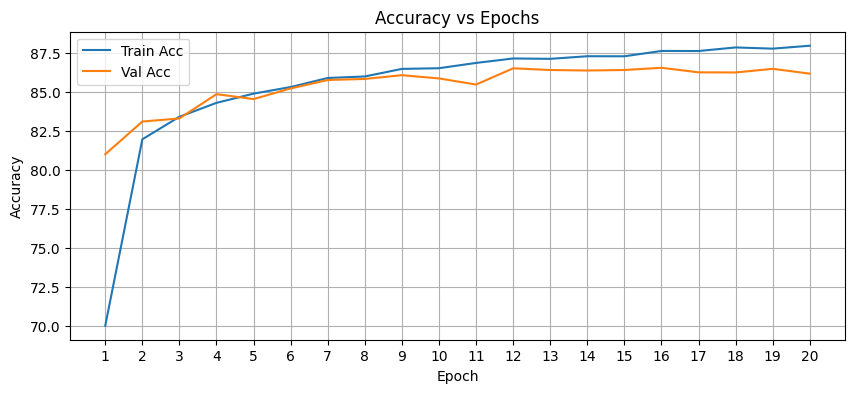

In [17]:
plt.figure(figsize=(10,4))

plt.plot(epoch_nums,train_accs,label="Train Acc")
plt.plot(epoch_nums,val_accs,label="Val Acc")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epoch_nums)
plt.legend()
plt.title("Accuracy vs Epochs")
plt.grid(True)
plt.show()

In [18]:
test_dataset = FashionMNIST(test_df)
test_loader = DataLoader(test_dataset,batch_size=64,shuffle=False)

In [19]:
with open("best_model.pkl", "rb") as f:# loading the best_model
    model.load_state_dict(pickle.load(f))
    
all_preds = []
all_labels = []

n_samples = 0
n_correct = 0

wrong_images = []
wrong_preds = []
wrong_labels = []

In [20]:
model.eval()# to evaluation mode

with torch.no_grad(): #to disable gradiant computation
    
    for images, labels in test_loader:
        
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy()) # for submission.csv

        ###############################
        
        n_samples += labels.shape[0]
        n_correct += (preds==labels).sum().item() # for accuracy calculation

        ###############################

        for img, pred, label in zip(images, preds, labels):# storing wrongly predicted images
            if pred.item() != label.item():
                wrong_images.append(img.cpu())
                wrong_preds.append(pred.item())
                wrong_labels.append(label.item())

In [21]:
print(f"Accuracy of the best model: {100*n_correct/n_samples}")

Accuracy of the best model: 86.75


In [22]:
submission_df = pd.DataFrame({
    "Actual": all_labels,
    "Prediction": all_preds
})
submission_df.to_csv("submission.csv", index=False)

print(submission_df)

      Actual  Prediction
0          0           0
1          1           1
2          2           2
3          2           2
4          3           3
...      ...         ...
9995       0           0
9996       6           6
9997       8           8
9998       8           8
9999       1           2

[10000 rows x 2 columns]


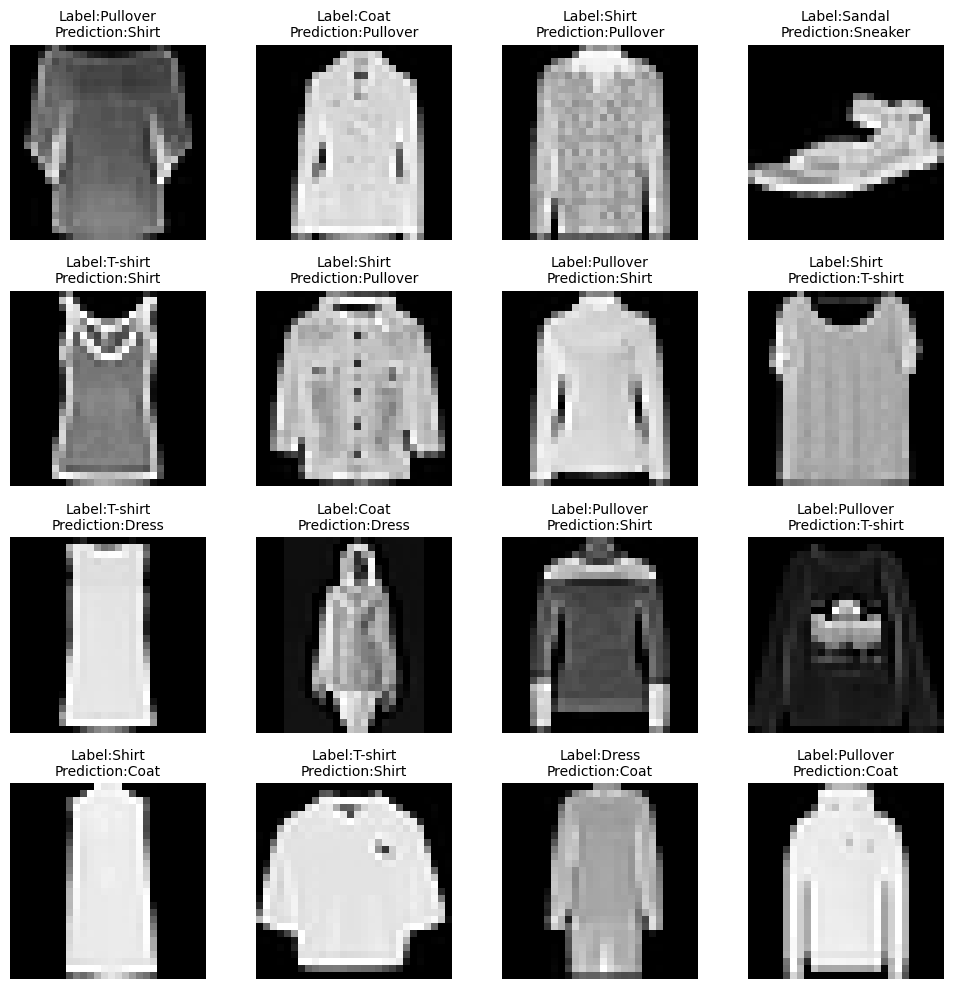

In [23]:
# visualizing wrongly predicted immages
plt.figure(figsize=(10, 10))

for i in range(min(16, len(wrong_images))):
    plt.subplot(4, 4, i + 1)

    plt.imshow(wrong_images[i].squeeze(), cmap="gray")

    plt.title(
        f"Label:{class_names[wrong_labels[i]]}\n"
        f"Prediction:{class_names[wrong_preds[i]]}",
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
#since we don't need labels for autoencoder
class FashionMNISTAutoencoder(Dataset):
    def __init__(self, dataframe):
        self.images = dataframe.iloc[:,1:].values.astype("float32") / 255.0

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = torch.tensor(self.images[idx]).reshape(1,28,28)
        return image

In [25]:
dataset2 = FashionMNISTAutoencoder(train_df) # create dataset objects

train_size2 = int(0.8 * len(dataset2))
val_size2 = int(0.2 * len(dataset2))

train_dataset2, val_dataset2 = random_split( dataset2, [train_size2, val_size2])

#creating data loaders for batch processing
train_loader2 = DataLoader(train_dataset2, batch_size=64, shuffle=True)
val_loader2 = DataLoader(val_dataset2, batch_size=64)

In [26]:
#this is autoencoder class
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(784,128),nn.ReLU(),

            nn.Linear(128,64),nn.ReLU(),

            nn.Linear(64,32),nn.ReLU()
        )

        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(32,64),nn.ReLU(),

            nn.Linear(64,128),nn.ReLU(),

            nn.Linear(128,784),

            nn.Sigmoid()# since we want output in range (0,1)
        )

    def forward(self,x):# forward propagation

        x = x.view(x.size(0),-1)

        latent = self.encoder(x) #

        reconstructed = self.decoder(latent)

        return reconstructed

In [27]:
encoder_model = AutoEncoder()

criterion2 = nn.MSELoss() # mean squared error
optimizer2 = torch.optim.Adam(encoder_model.parameters(), lr=0.001)

ae_train_losses = []
ae_val_losses = []

In [28]:
# to get the reconstructed images close to original images
for epoch in range(epochs):

    encoder_model.train() # to training mode

    running_train_loss = 0

    for images in train_loader2:

        outputs = encoder_model(images)

        loss = criterion2(outputs,images.view(images.size(0), -1))
        
        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader2)

    encoder_model.eval() # to evaluation mode

    running_val_loss = 0

    with torch.no_grad():

        for images in val_loader2:

            outputs = encoder_model(images)

            loss = criterion2(outputs,images.view(images.size(0), -1))

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader2)

    ae_train_losses.append(train_loss)
    ae_val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}]"
        f"Training Loss: {train_loss:.6f} "
        f"Validation Loss: {val_loss:.6f}"
    )

Epoch [1/20]Training Loss: 0.039104 Validation Loss: 0.024233
Epoch [2/20]Training Loss: 0.022476 Validation Loss: 0.021046
Epoch [3/20]Training Loss: 0.020086 Validation Loss: 0.019186
Epoch [4/20]Training Loss: 0.018551 Validation Loss: 0.018109
Epoch [5/20]Training Loss: 0.017582 Validation Loss: 0.017080
Epoch [6/20]Training Loss: 0.016633 Validation Loss: 0.016377
Epoch [7/20]Training Loss: 0.015730 Validation Loss: 0.015325
Epoch [8/20]Training Loss: 0.015058 Validation Loss: 0.014879
Epoch [9/20]Training Loss: 0.014538 Validation Loss: 0.014403
Epoch [10/20]Training Loss: 0.014140 Validation Loss: 0.014111
Epoch [11/20]Training Loss: 0.013801 Validation Loss: 0.013787
Epoch [12/20]Training Loss: 0.013493 Validation Loss: 0.013451
Epoch [13/20]Training Loss: 0.013225 Validation Loss: 0.013277
Epoch [14/20]Training Loss: 0.013000 Validation Loss: 0.012934
Epoch [15/20]Training Loss: 0.012781 Validation Loss: 0.012754
Epoch [16/20]Training Loss: 0.012618 Validation Loss: 0.012699
E

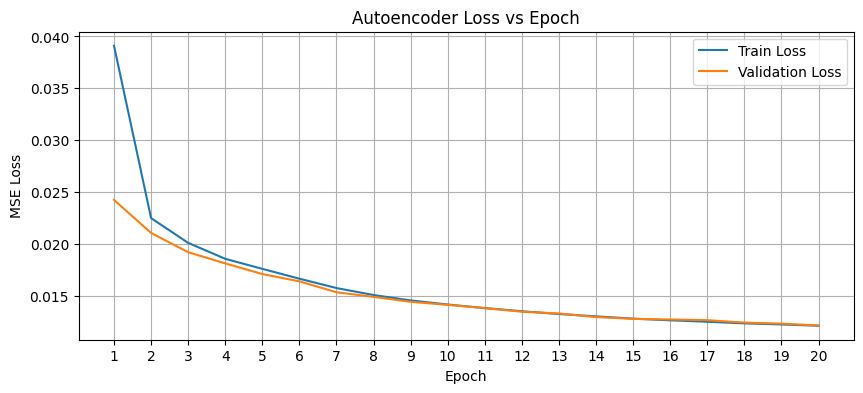

In [29]:
epoch_nums = range(1, epochs + 1)

plt.figure(figsize=(10,4))

plt.plot(epoch_nums, ae_train_losses, label="Train Loss")
plt.plot(epoch_nums, ae_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.xticks(epoch_nums)
plt.legend()

plt.title("Autoencoder Loss vs Epoch")
plt.grid(True)

plt.show()

In [30]:
with open("best_autoencoder.pkl", "wb") as f:
    pickle.dump(encoder_model.state_dict(), f)

In [31]:
best_encoder_model = AutoEncoder()

with open("best_autoencoder.pkl", "rb") as f:
    best_encoder_model.load_state_dict(pickle.load(f))

best_encoder_model.eval()

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

In [32]:
test_dataset2 = FashionMNISTAutoencoder(test_df)
test_loader2 = DataLoader(test_dataset2, batch_size=64, shuffle=False)

In [33]:
best_encoder_model.eval()

with torch.no_grad():

    images = next(iter(test_loader2))

    reconstructed = best_encoder_model(images)
    reconstructed = reconstructed.view(-1,1,28,28)

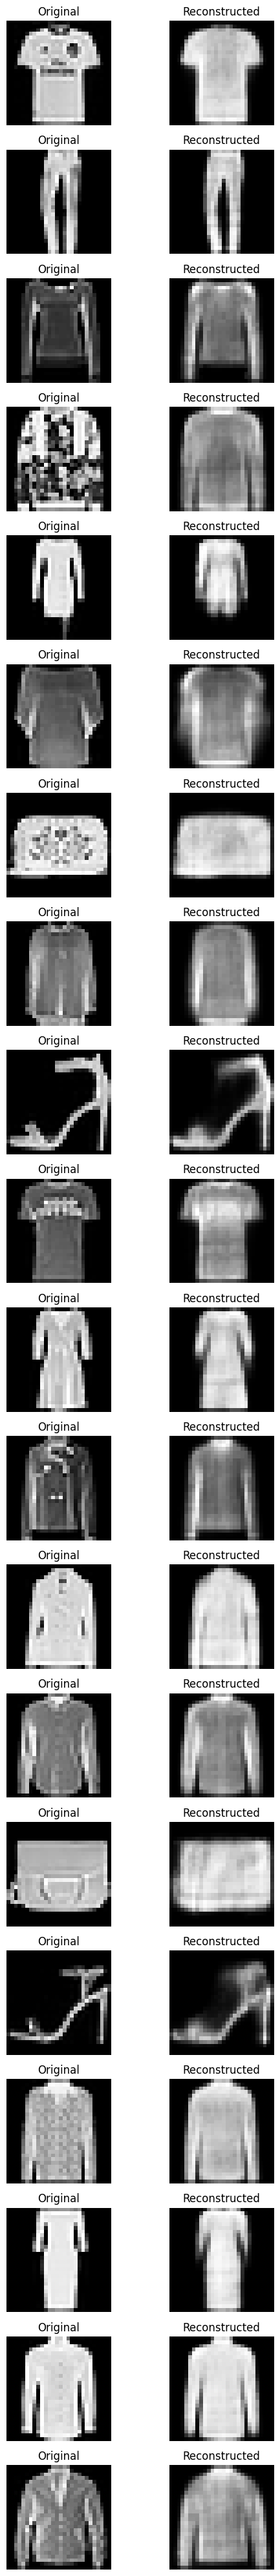

In [34]:
fig, axes = plt.subplots(20,2,figsize=(6,40))

for i in range(20):

    axes[i,0].imshow(images[i].squeeze(),cmap="gray")
    axes[i,0].set_title("Original")
    axes[i,0].axis("off")

    axes[i,1].imshow(reconstructed[i].squeeze(),cmap="gray")
    axes[i,1].set_title("Reconstructed")
    axes[i,1].axis("off")

plt.tight_layout()
plt.show()